In [9]:
import time
from io import StringIO
from typing import List, Optional, Union, Dict

import numpy as np
import pandas as pd
import requests


# =========================================================
# 0) 지역(국가/집계) 코드 매핑
#    - OECD DF_CLI는 REF_AREA에 ISO3 국가코드와 G20 같은 집계코드를 씁니다. :contentReference[oaicite:2]{index=2}
# =========================================================
OECD_AREA_MAP: Dict[str, str] = {
    # aggregates
    "G20": "G20",

    # countries (ISO3)
    "한국": "KOR", "KOR": "KOR",
    "미국": "USA", "USA": "USA",
    "일본": "JPN", "JPN": "JPN",

    "멕시코": "MEX", "MEX": "MEX",
    "영국": "GBR", "GBR": "GBR", "UK": "GBR",
    "프랑스": "FRA", "FRA": "FRA",
    "스페인": "ESP", "ESP": "ESP",
    "독일": "DEU", "DEU": "DEU", "GER": "DEU",
    "이탈리아": "ITA", "ITA": "ITA",
    "오스트레일리아": "AUS", "AUS": "AUS",
    "캐나다": "CAN", "CAN": "CAN",
}


def resolve_oecd_areas(items: List[str]) -> List[str]:
    out = []
    for x in items:
        x = str(x).strip()
        code = OECD_AREA_MAP.get(x, x)  # 매핑 없으면 입력 그대로(이미 ISO3일 수 있음)
        out.append(code)
    # 중복 제거(순서 유지)
    seen = set()
    uniq = []
    for c in out:
        if c not in seen:
            uniq.append(c)
            seen.add(c)
    return uniq


# =========================================================
# 1) OECD CLI API 수집
#   - OECD 공식 API 문서 예시: /public/rest/data/OECD.SDD.STES,DSD_STES@DF_CLI/... :contentReference[oaicite:3]{index=3}
#   - G20 조회 예시는 dq=G20.M.LI...AA...H 형태로 공개되어 있음 :contentReference[oaicite:4]{index=4}
# =========================================================
def fetch_oecd_cli(
    areas: List[str],
    start_period: str = "1990-01",
    end_period: Optional[str] = None,
    timeout: int = 60,
    sleep_sec: float = 0.15,
    use_labels: bool = True,
) -> pd.DataFrame:
    """
    areas: REF_AREA 코드 리스트 (예: ["G20","KOR","USA","JPN","GBR","DEU"...])
    key: {REF_AREA}.M.LI...AA...H  (월별 CLI, amplitude-adjusted, harmonised)
    """
    base = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.STES,DSD_STES@DF_CLI,4.1"

    # 여러 국가를 + 로 묶어서 한 번에 호출 가능
    area_part = "+".join(areas)
    key = f"{area_part}.M.LI...AA...H"

    params = {
        "startPeriod": start_period,
        "dimensionAtObservation": "AllDimensions",
        "format": "csvfilewithlabels" if use_labels else "csvfile",
    }
    if end_period:
        params["endPeriod"] = end_period

    url = f"{base}/{key}"

    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; OECD-CLI-fetcher/1.0)",
        "Accept": "text/csv",
    }

    r = requests.get(url, params=params, headers=headers, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError(f"OECD API failed: {r.status_code} / {r.text[:300]}")

    df = pd.read_csv(StringIO(r.text))
    time.sleep(sleep_sec)
    return df


# =========================================================
# 2) 국면 분류 (확장/둔화/저점/회복)
#   - 기준: 레벨(100) vs 모멘텀(+)의 4분면
# =========================================================
def classify_cli_phases(
    df_cli: pd.DataFrame,
    threshold: float = 100.0,
    mom_window: int = 3,
) -> pd.DataFrame:
    """
    확장: cli>=100 & mom>0
    둔화: cli>=100 & mom<0
    저점: cli<100 & mom<0
    회복: cli<100 & mom>0
    """

    df = df_cli.copy()

    # 컬럼 자동 탐색 (csvfilewithlabels / csvfile 차이 대응)
    candidates = {
        "area": ["REF_AREA", "Reference area", "LOCATION", "REF_AREA (code)"],
        "time": ["TIME_PERIOD", "Time period"],
        "cli":  ["OBS_VALUE", "Observation Value", "OBS_VALUE (value)"],
    }

    def pick(colkey):
        for c in candidates[colkey]:
            if c in df.columns:
                return c
        raise KeyError(f"필수 컬럼({colkey})을 찾지 못했습니다. cols={list(df.columns)[:50]}")

    acol, tcol, vcol = pick("area"), pick("time"), pick("cli")

    df = df.rename(columns={acol: "area", tcol: "time", vcol: "cli"})
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df["cli"] = pd.to_numeric(df["cli"], errors="coerce")
    df = df.dropna(subset=["area", "time", "cli"]).sort_values(["area", "time"]).reset_index(drop=True)

    df["mom"] = df.groupby("area")["cli"].diff(mom_window)

    above = df["cli"] >= threshold
    up = df["mom"] > 0
    down = df["mom"] < 0

    df["phase"] = np.select(
        [
            df["mom"].isna(),
            above & up,
            above & down,
            (~above) & down,
            (~above) & up,
            df["mom"] == 0,
        ],
        [
            np.nan,
            "확장",
            "둔화",
            "저점",
            "회복",
            "중립",
        ],
        default="중립",
    )

    df["phase_change"] = df.groupby("area")["phase"].transform(lambda s: s.ne(s.shift(1)))

    return df


# =========================================================
# 3) 한 번에 실행 (요청 국가 + G20 포함)
# =========================================================
def get_cli_with_phases(
    targets: Optional[List[str]] = None,
    start_period: str = "2008-01",
    end_period: Optional[str] = None,
    mom_window: int = 3,
) -> pd.DataFrame:
    """
    targets에 한글/영문/ISO3 섞어서 넣어도 됨.
    예: ["G20","멕시코","영국","프랑스","스페인","독일","이탈리아","오스트레일리아","캐나다"]
    """
    if targets is None:
        targets = [
            "G20",
            "멕시코", "영국", "프랑스", "스페인", "독일", "이탈리아", "오스트레일리아", "캐나다",
            "한국", "미국", "일본",
        ]

    areas = resolve_oecd_areas(targets)

    raw = fetch_oecd_cli(
        areas=areas,
        start_period=start_period,
        end_period=end_period,
        use_labels=True
    )
    out = classify_cli_phases(raw, mom_window=mom_window)
    return out


# ===========================
# 사용 예시
# ===========================
# if __name__ == "__main__":
#     df = get_cli_with_phases(
#         targets=["G20","멕시코","영국","프랑스","스페인","독일","이탈리아","오스트레일리아","캐나다"],
#         start_period="2008-01",
#         mom_window=3
#     )
#     print(df[df["area"].isin(["G20","MEX","GBR","FRA","ESP","DEU","ITA","AUS","CAN"])].tail(20))


In [12]:
df = get_cli_with_phases(
    targets=["G20","멕시코","영국","프랑스","스페인","독일","이탈리아","오스트레일리아","캐나다"],
    start_period="2008-01",
    mom_window=3)

# print(df[df["area"].isin(["G20","MEX","GBR","FRA","ESP","DEU","ITA","AUS","CAN"])].tail(20))
print(df[df["area"].isin(["G20"])].tail(20))

     STRUCTURE                        STRUCTURE_ID  \
1282  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1283  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1284  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1285  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1286  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1287  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1288  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1289  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1290  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1291  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1292  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1293  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1294  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1295  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1296  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1297  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1298  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1299  DATAFLOW  OECD.SDD.STE

In [14]:
G20 = df[df["area"].isin(["G20"])]

<AxesSubplot: >

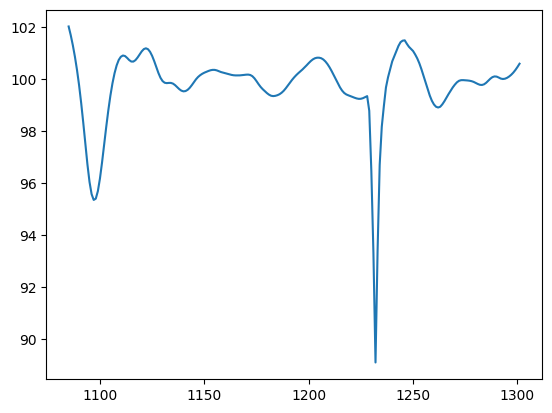

In [16]:
G20['cli'].plot()

In [19]:
import time
from io import StringIO
from typing import List, Optional, Dict

import numpy as np
import pandas as pd
import requests

DATA_ENDPOINT = "https://sdmx.oecd.org/public/rest/data"


# =========================================================
# 1) OECD CSV fetch (버전 생략 → 최신 자동)
#   - OECD FAQ 예시도 버전 없이 호출함 :contentReference[oaicite:1]{index=1}
# =========================================================
def fetch_oecd_csv(
    resource_id: str,   # 예: "OECD.SDD.STES,DSD_STES@DF_CLI"  (버전 생략)
    key: str,
    start_period: str,
    end_period: Optional[str] = None,
    timeout: int = 60,
    labels: bool = True,
    sleep_sec: float = 0.15,
) -> pd.DataFrame:
    params = {
        "startPeriod": start_period,
        "dimensionAtObservation": "AllDimensions",
        "format": "csvfilewithlabels" if labels else "csvfile",
    }
    if end_period:
        params["endPeriod"] = end_period

    url = f"{DATA_ENDPOINT}/{resource_id}/{key}"

    r = requests.get(url, params=params, timeout=timeout, headers={"Accept": "text/csv"})
    if r.status_code != 200:
        raise RuntimeError(f"OECD API failed: {r.status_code} / {r.text[:400]}")

    time.sleep(sleep_sec)
    return pd.read_csv(StringIO(r.text))


# =========================================================
# 2) CLI 수집 + 국면분류
#   key 패턴: {AREA}.M.LI...AA...H (OECD 예시 패턴) :contentReference[oaicite:2]{index=2}
# =========================================================
def fetch_cli_and_phase(
    areas: List[str],
    start_period: str = "2000-01",
    end_period: Optional[str] = None,
    mom_window: int = 3,
    threshold: float = 100.0,
) -> pd.DataFrame:
    resource_id = "OECD.SDD.STES,DSD_STES@DF_CLI"

    area_part = "+".join(areas)
    key = f"{area_part}.M.LI...AA...H"

    raw = fetch_oecd_csv(resource_id, key, start_period, end_period, labels=True)

    def pick(df, cands):
        for c in cands:
            if c in df.columns:
                return c
        raise KeyError(f"Cannot find columns among: {cands} / got={list(df.columns)[:60]}")

    area_col = pick(raw, ["REF_AREA", "Reference area", "REF_AREA (code)", "LOCATION"])
    time_col = pick(raw, ["TIME_PERIOD", "Time period"])
    val_col  = pick(raw, ["OBS_VALUE", "Observation Value", "OBS_VALUE (value)"])

    df = raw.rename(columns={area_col: "area", time_col: "date", val_col: "cli"}).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["cli"] = pd.to_numeric(df["cli"], errors="coerce")
    df = df.dropna(subset=["area", "date", "cli"]).sort_values(["area", "date"]).reset_index(drop=True)

    df["mom"] = df.groupby("area")["cli"].diff(mom_window)

    above = df["cli"] >= threshold
    up = df["mom"] > 0
    down = df["mom"] < 0

    df["phase"] = np.select(
        [
            df["mom"].isna(),
            above & up,
            above & down,
            (~above) & down,
            (~above) & up,
            df["mom"] == 0,
        ],
        [np.nan, "확장", "둔화", "저점", "회복", "중립"],
        default="중립",
    )

    # ✅ apply 대신 transform 사용(이전 에러 방지)
    df["phase_change"] = df.groupby("area")["phase"].transform(lambda s: s.ne(s.shift(1)))

    return df


# =========================================================
# 3) 금리 수집 (DF_FINMARK) - 단기/장기
#   - DF_FINMARK UI/예시에서 IRLT/IR3TIB 패턴 사용됨 :contentReference[oaicite:3]{index=3}
# =========================================================
def fetch_finmark_rates(
    areas: List[str],
    start_period: str = "2000-01",
    end_period: Optional[str] = None,
    freq: str = "M",          # "M"(월) or "A"(연)
    rate_code: str = "IR3TIB",# 단기: IR3TIB, 장기: IRLT
    measure: str = "PA",      # percent per annum
) -> pd.DataFrame:
    resource_id = "OECD.SDD.STES,DSD_STES@DF_FINMARK"

    area_part = "+".join(areas)
    key = f"{area_part}.{freq}.{rate_code}.{measure}....."

    raw = fetch_oecd_csv(resource_id, key, start_period, end_period, labels=True)

    def pick(df, cands):
        for c in cands:
            if c in df.columns:
                return c
        raise KeyError(f"Cannot find columns among: {cands} / got={list(df.columns)[:60]}")

    area_col = pick(raw, ["REF_AREA", "Reference area", "REF_AREA (code)", "LOCATION"])
    time_col = pick(raw, ["TIME_PERIOD", "Time period"])
    val_col  = pick(raw, ["OBS_VALUE", "Observation Value", "OBS_VALUE (value)"])

    df = raw.rename(columns={area_col: "area", time_col: "date", val_col: "value"}).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["area", "date"]).sort_values(["area", "date"]).reset_index(drop=True)

    df["indicator"] = f"{rate_code}_{measure}_{freq}"
    return df[["date", "area", "indicator", "value"]]


# =========================================================
# 4) 한 번에: CLI+국면 + 금리(단기/장기)
# =========================================================
def collect_oecd_core_macro(
    areas: List[str],
    start_period: str = "2008-01",
    end_period: Optional[str] = None,
    mom_window: int = 3,
) -> Dict[str, pd.DataFrame]:

    cli_phase = fetch_cli_and_phase(
        areas=areas, start_period=start_period, end_period=end_period,
        mom_window=mom_window
    )

    # 단기금리(월): IR3TIB
    r_short = fetch_finmark_rates(
        areas=areas, start_period=start_period, end_period=end_period,
        freq="M", rate_code="IR3TIB", measure="PA"
    )

    # 장기금리(연): IRLT (연간이 일반적)
    # start_period을 연도로 맞춤
    start_year = start_period[:4]
    end_year = end_period[:4] if end_period else None
    r_long = fetch_finmark_rates(
        areas=areas, start_period=start_year, end_period=end_year,
        freq="A", rate_code="IRLT", measure="PA"
    )

    rates_long = pd.concat([r_short, r_long], ignore_index=True)

    return {"cli_phase": cli_phase, "rates_long": rates_long}


# ===========================
# 사용 예시
# ===========================
# if __name__ == "__main__":
#     areas = ["G20","KOR","USA","JPN","GBR","FRA","ESP","DEU","ITA","AUS","CAN","MEX"]
#     out = collect_oecd_core_macro(areas, start_period="2008-01", mom_window=3)
#     print(out["cli_phase"].tail(10))
#     print(out["rates_long"].tail(10))


In [20]:
areas = ["G20","KOR","USA","JPN","GBR","FRA","ESP","DEU","ITA","AUS","CAN","MEX"]
out = collect_oecd_core_macro(areas, start_period="2008-01", mom_window=3)
print(out["cli_phase"].tail(10))
print(out["rates_long"].tail(10))

     STRUCTURE                        STRUCTURE_ID  \
2594  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2595  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2596  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2597  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2598  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2599  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2600  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2601  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2602  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
2603  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   

                    STRUCTURE_NAME ACTION area Reference area FREQ  \
2594  Composite leading indicators      I  USA  United States    M   
2595  Composite leading indicators      I  USA  United States    M   
2596  Composite leading indicators      I  USA  United States    M   
2597  Composite leading indicators      I  USA  United States    M   
2598  Composite leading indicators      I  USA  United 

In [23]:
df = out['cli_phase']

df[df['area'] == 'G20']

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,area,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals,BASE_PER,Base period,mom,phase,phase_change
1085,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,NaN,nan,True
1086,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,NaN,nan,False
1087,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,NaN,nan,False
1088,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,-1.1608,둔화,True
1089,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,-1.3370,둔화,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1297,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,0.1515,확장,False
1298,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,0.2012,확장,False
1299,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,0.2504,확장,False
1300,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,G20,G20,M,Monthly,LI,Composite leading indicator (CLI),...,Normal value,0,Units,2,Two,NaN,NaN,0.2995,확장,False
